In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q scikit-learn opencv-python-headless


In [ ]:
import os, glob, shutil, cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score,
    precision_score, recall_score, f1_score
)
from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cuda


In [ ]:
base_dir        = '/content/drive/MyDrive/breast cancer'
train_dir       = os.path.join(base_dir, 'train')
valid_dir       = os.path.join(base_dir, 'valid')
test_dir        = os.path.join(base_dir, 'test-1')
processed_dir   = os.path.join(base_dir, 'processed_v3')
processed_train = os.path.join(processed_dir, 'train')
processed_valid = os.path.join(processed_dir, 'valid')
processed_test  = os.path.join(processed_dir, 'test')
model_path      = '/content/drive/MyDrive/best_efficientnet_v3.pth'
IMG_SIZE        = 224


In [ ]:
def load_image_grayscale(file_path):
    """Load any image as grayscale float32, range [0, 1]."""
    try:
        if file_path.lower().endswith('.dcm'):
            import pydicom
            dcm = pydicom.dcmread(file_path)
            img = dcm.pixel_array.astype(np.float32)
            if dcm.PhotometricInterpretation == "MONOCHROME1":
                img = img.max() - img
        else:
            img = np.array(Image.open(file_path).convert('L'), dtype=np.float32)
        return (img - img.min()) / (img.max() - img.min() + 1e-8)
    except Exception as e:
        print(f"Load error {file_path}: {e}")
        return None


In [ ]:
def is_white_background(image, wr_thresh=0.3, br_thresh=0.5, mean_thresh=0.7):
    """Returns True if image has a white background."""
    wr = (image > 0.95).sum() / image.size
    br = (image > 0.80).sum() / image.size
    if wr > wr_thresh or br > br_thresh:
        return True
    if image.mean() > mean_thresh and image.std() < 0.2:
        return True
    return False


In [ ]:
def create_breast_mask(image):
    """
    Create binary breast mask using Otsu + morphological ops.
    This mask is ONLY used to find the bounding box for cropping.
    It does NOT zero out any pixels inside the breast.
    """
    img_uint8 = (image * 255).astype(np.uint8)
    _, binary = cv2.threshold(img_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

    # Keep only the largest connected component (= breast)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, 8)
    if num_labels <= 1:
        return (binary > 0).astype(np.uint8)
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return (labels == largest).astype(np.uint8)


In [ ]:
def crop_and_pad(image, mask, target_size=224):
    """
    Use mask bounding box to crop the breast region from the ORIGINAL image.
    Then pad to square (preserves aspect ratio) and resize.

    Key: the original pixels are NEVER zeroed out or modified.
    The mask is only a "locator tool" — once cropping is done, its job is over.

    Returns:
        processed_img:  float32 (target_size, target_size), original pixels preserved
        processed_mask: uint8   (target_size, target_size), for soft attention guidance
    """
    coords = np.argwhere(mask > 0)
    if len(coords) == 0:
        # No breast found — use entire image
        r0, c0 = 0, 0
        r1, c1 = image.shape
    else:
        r0, c0 = coords.min(axis=0)
        r1, c1 = coords.max(axis=0) + 1

    # Crop ORIGINAL image (not masked!) — all internal info preserved
    cropped_img  = image[r0:r1, c0:c1]
    cropped_mask = mask[r0:r1, c0:c1]

    # Pad to square
    ch, cw = cropped_img.shape
    max_side = max(ch, cw)
    pad_h = (max_side - ch) // 2
    pad_w = (max_side - cw) // 2

    padded_img = np.zeros((max_side, max_side), dtype=np.float32)
    padded_img[pad_h:pad_h+ch, pad_w:pad_w+cw] = cropped_img

    padded_mask = np.zeros((max_side, max_side), dtype=np.uint8)
    padded_mask[pad_h:pad_h+ch, pad_w:pad_w+cw] = cropped_mask

    # Resize
    proc_img  = cv2.resize(padded_img,  (target_size, target_size), interpolation=cv2.INTER_LINEAR)
    proc_mask = cv2.resize(padded_mask, (target_size, target_size), interpolation=cv2.INTER_NEAREST)

    return proc_img, proc_mask


In [ ]:
def preprocess_and_save_all(src_dir, dst_dir, target_size=224):
    """
    Pipeline: Load → White-BG filter → Breast mask (for bbox only) → Crop → Pad → Save
    No pectoral removal. No internal pixel modification.
    """
    total = {'processed': 0, 'white_skipped': 0, 'failed': 0, 'exist': 0}

    for cls in ['0', '1']:
        src_cls = os.path.join(src_dir, cls)
        dst_cls = os.path.join(dst_dir, cls)
        os.makedirs(dst_cls, exist_ok=True)
        files = glob.glob(os.path.join(src_cls, '*'))
        split_name = os.path.basename(src_dir)
        print(f"\n  {split_name}/class_{cls}: {len(files)} files")

        for f in tqdm(files, desc=f"Class {cls}"):
            fname = os.path.splitext(os.path.basename(f))[0]
            save_path = os.path.join(dst_cls, f"{fname}.npz")
            if os.path.exists(save_path):
                total['exist'] += 1; continue

            image = load_image_grayscale(f)
            if image is None:
                total['failed'] += 1; continue
            if is_white_background(image):
                total['white_skipped'] += 1; continue

            mask = create_breast_mask(image)
            proc_img, proc_mask = crop_and_pad(image, mask, target_size)
            np.savez_compressed(save_path, image=proc_img, mask=proc_mask)
            total['processed'] += 1

    print(f"\n  Done: processed={total['processed']}, exist={total['exist']}, "
          f"white_skipped={total['white_skipped']}, failed={total['failed']}")
    return total


if os.path.exists(processed_dir):
    shutil.rmtree(processed_dir)
    print("Cleared old data.\n")

print("=" * 70)
print("Step 1: Preprocess (white-BG filter + crop breast region, no internal masking)")
print("=" * 70)

for name, src, dst in [('train', train_dir, processed_train),
                        ('valid', valid_dir, processed_valid),
                        ('test',  test_dir,  processed_test)]:
    print(f"\n--- {name.upper()} ---")
    preprocess_and_save_all(src, dst, IMG_SIZE)


Cleared old data.

Step 1: Preprocess (white-BG filter + crop breast region, no internal masking)

--- TRAIN ---

  train/class_0: 1569 files


Class 0:  13%|█▎        | 209/1569 [00:32<01:07, 20.13it/s]

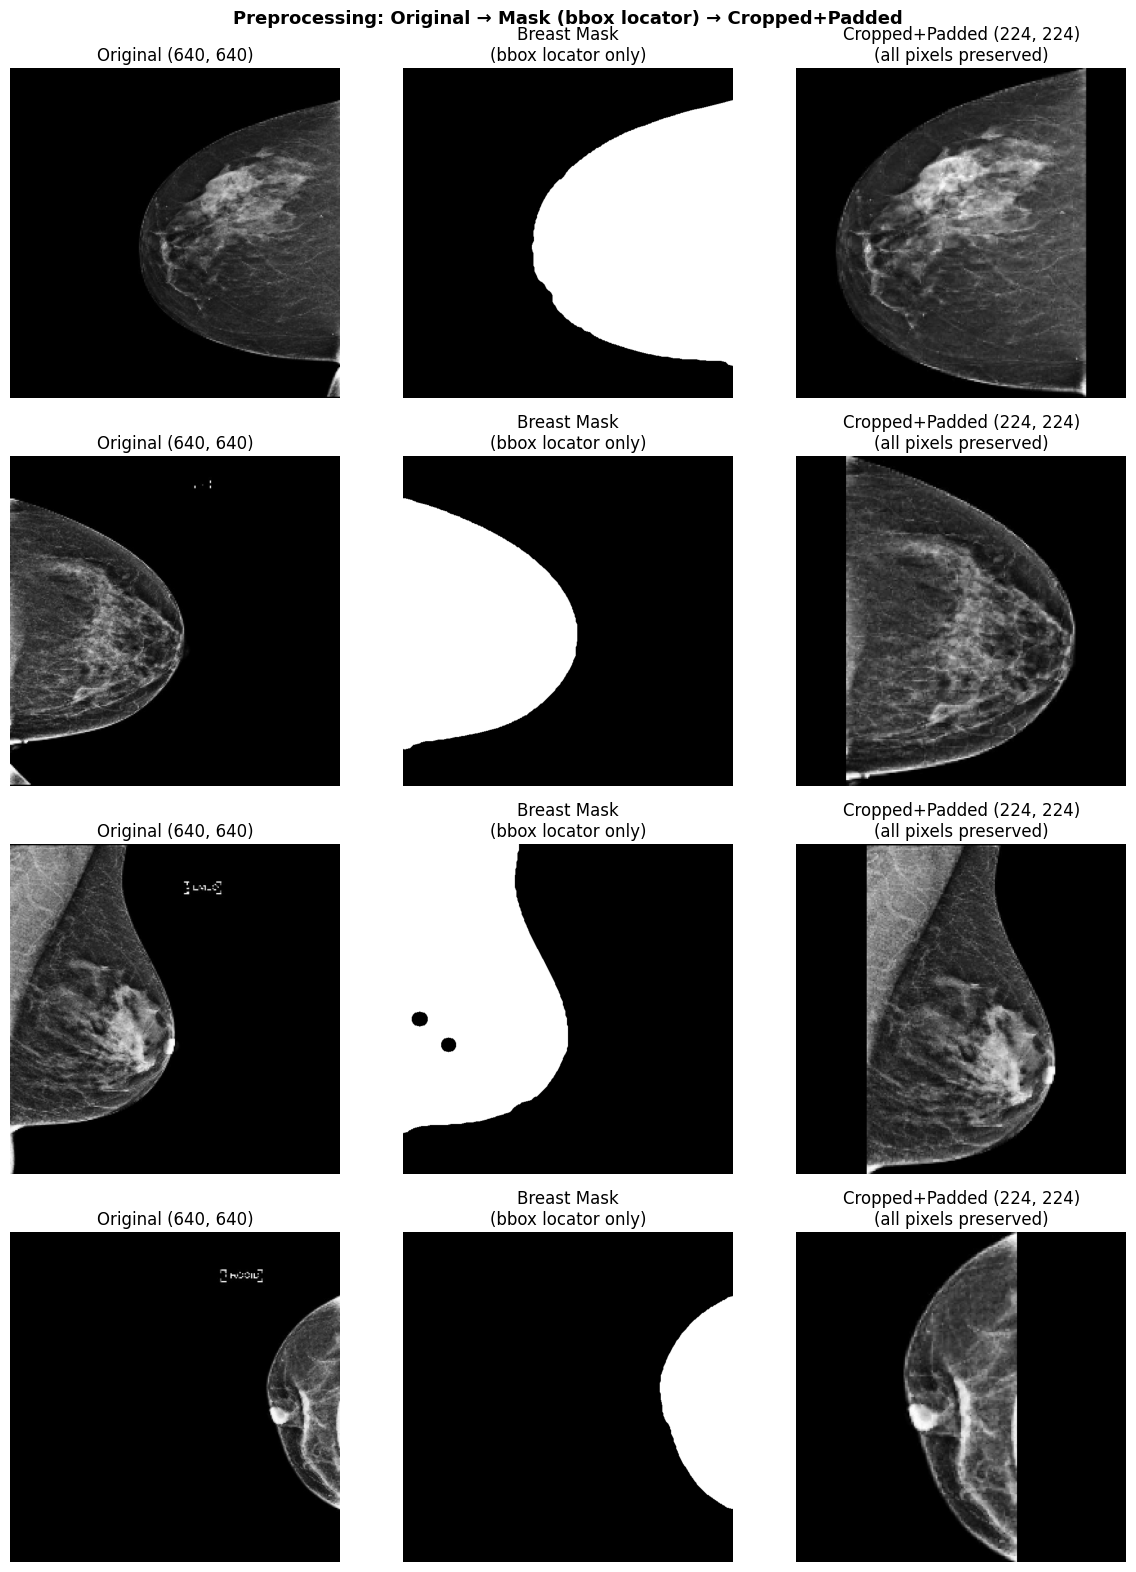

In [ ]:
def visualize_pipeline(src_dir, dst_dir, cls='1', n=4):
    """Show: Original → Breast Mask → Cropped+Padded (original pixels preserved)"""
    pairs = []
    for sf in glob.glob(os.path.join(src_dir, cls, '*')):
        fname = os.path.splitext(os.path.basename(sf))[0]
        npz = os.path.join(dst_dir, cls, f"{fname}.npz")
        if os.path.exists(npz):
            pairs.append((sf, npz))
        if len(pairs) >= n: break

    fig, axes = plt.subplots(len(pairs), 3, figsize=(12, 4*len(pairs)))
    if len(pairs) == 1: axes = axes.reshape(1, -1)
    fig.suptitle('Preprocessing: Original → Mask (bbox locator) → Cropped+Padded',
                 fontsize=13, fontweight='bold')
    for i, (sf, npz) in enumerate(pairs):
        orig = load_image_grayscale(sf)
        data = np.load(npz)
        axes[i,0].imshow(orig, cmap='gray'); axes[i,0].set_title(f'Original {orig.shape}'); axes[i,0].axis('off')
        mask = create_breast_mask(orig)
        axes[i,1].imshow(mask, cmap='gray'); axes[i,1].set_title('Breast Mask\n(bbox locator only)'); axes[i,1].axis('off')
        axes[i,2].imshow(data['image'], cmap='gray'); axes[i,2].set_title(f'Cropped+Padded {data["image"].shape}\n(all pixels preserved)'); axes[i,2].axis('off')
    plt.tight_layout(); plt.savefig(os.path.join(base_dir, 'preprocessing_v3.png'), dpi=150, bbox_inches='tight'); plt.show()

visualize_pipeline(train_dir, processed_train, cls='1', n=4)


In [ ]:
def build_file_list(data_dir):
    files, labels = [], []
    for cls in ['0', '1']:
        cls_files = glob.glob(os.path.join(data_dir, cls, '*.npz'))
        files.extend(cls_files)
        labels.extend([int(cls)] * len(cls_files))
    return files, labels

train_files, train_labels = build_file_list(processed_train)
valid_files, valid_labels = build_file_list(processed_valid)
test_files,  test_labels  = build_file_list(processed_test)
print(f'Train: {len(train_files)} (c0={train_labels.count(0)}, c1={train_labels.count(1)})')
print(f'Valid: {len(valid_files)} | Test: {len(test_files)}')


class MammogramDataset(Dataset):
    """
    Loads .npz containing image (H,W) and mask (H,W).
    Returns image as (1,H,W) single-channel tensor + mask + label.
    """
    def __init__(self, files, labels, augment=False):
        self.files = files
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data  = np.load(self.files[idx])
        image = data['image'].astype(np.float32)
        mask  = data['mask'].astype(np.float32)
        label = self.labels[idx]

        # Simple augmentation (applied consistently to image and mask)
        if self.augment:
            if np.random.rand() > 0.5:
                image = np.flip(image, axis=0).copy()
                mask  = np.flip(mask, axis=0).copy()
            if np.random.rand() > 0.5:
                image = np.flip(image, axis=1).copy()
                mask  = np.flip(mask, axis=1).copy()
            if np.random.rand() > 0.5:
                k = np.random.choice([1, 2, 3])
                image = np.rot90(image, k).copy()
                mask  = np.rot90(mask, k).copy()
            # Brightness jitter
            if np.random.rand() > 0.7:
                image = np.clip(image + np.random.uniform(-0.05, 0.05), 0, 1)
            # Gaussian noise
            if np.random.rand() > 0.8:
                image = np.clip(image + np.random.randn(*image.shape) * 0.03, 0, 1).astype(np.float32)

        image = torch.from_numpy(image[np.newaxis, ...])  # (1, H, W)
        mask  = torch.from_numpy(mask[np.newaxis, ...])    # (1, H, W)
        return image, mask, label


Train: 2007 (c0=1303, c1=704)
Valid: 552 | Test: 412


In [ ]:
BATCH_SIZE  = 4
NUM_WORKERS = 2

train_ds = MammogramDataset(train_files, train_labels, augment=True)
valid_ds = MammogramDataset(valid_files, valid_labels, augment=False)
test_ds  = MammogramDataset(test_files,  test_labels,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

img, msk, lbl = train_ds[0]
print(f'Sample: image={img.shape}, mask={msk.shape}, label={lbl}')


Sample: image=torch.Size([1, 224, 224]), mask=torch.Size([1, 224, 224]), label=0


In [ ]:
class SoftGuidedAttention(nn.Module):
    """
    Soft-guided spatial attention for medical imaging.

    How it works:
      1. Learns a spatial attention map from feature maps (self-attention)
      2. Uses the breast mask as a SOFT prior (not hard gate)
      3. Learnable alpha controls mask influence:
         - alpha -> 0: mask has no effect, pure self-attention
         - alpha -> 1: mask strongly guides attention
         - alpha is learned during training, model decides automatically

    Key difference from hard masking:
      - Hard mask: attention outside breast = 0 (information destroyed)
      - Soft guide: attention outside breast = reduced but NOT zero (info preserved)

    This prevents the mask from destroying edge/boundary information
    while still encouraging the model to focus inside the breast.
    """
    def __init__(self, in_channels):
        super().__init__()
        self.spatial_conv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 4, kernel_size=1, bias=False),
            nn.BatchNorm2d(in_channels // 4),
            nn.ReLU(inplace=False),
            nn.Conv2d(in_channels // 4, 1, kernel_size=1, bias=False),
            nn.Sigmoid()
        )
        # Learnable parameter: how much should the mask influence attention
        # Initialized at 0.0 -> sigmoid(0.0) = 0.5 -> moderate influence
        self.alpha_raw = nn.Parameter(torch.tensor(0.0))

    def forward(self, x, mask=None):
        """
        Args:
            x:    feature maps (B, C, H', W')
            mask: breast mask (B, 1, H, W), optional
        """
        spatial_att = self.spatial_conv(x)  # (B, 1, H', W')

        if mask is not None:
            # Downsample mask to feature map resolution
            mask_down = F.interpolate(mask, size=spatial_att.shape[2:],
                                      mode='bilinear', align_corners=False)
            alpha = torch.sigmoid(self.alpha_raw)

            # Soft gate: breast region -> ~1.0, outside -> (1-alpha) > 0
            soft_gate = alpha * mask_down + (1.0 - alpha)
            spatial_att = spatial_att * soft_gate

        return x * spatial_att


In [ ]:
class EfficientNetSoftAttention(nn.Module):
    """
    EfficientNet-B0 backbone (single-channel input) + Soft-Guided Attention.

    Architecture:
      Input (1, 224, 224)
        → EfficientNet-B0 features (1280, 7, 7)
        → Soft-Guided Spatial Attention
        → Global Average Pool → Dropout → FC(1280, 256) → FC(256, 2)
        → Output: Benign/Malignant

    Why EfficientNet-B0:
      - Only 5.3M params (good for small dataset ~2400 images)
      - Built-in SE attention in every MBConv block
      - ImageNet pretrained weights available
      - Compound scaling: depth/width/resolution optimized together

    Why single channel (not 3-ch copy):
      - Mammograms are grayscale, copying to 3-ch adds no information
      - 1-ch input reduces computation by ~3x in first conv layer
      - First conv weights adapted from pretrained 3-ch by averaging
    """
    def __init__(self, num_classes=2, dropout_rate=0.4, pretrained=True):
        super().__init__()

        # Load pretrained EfficientNet-B0
        if pretrained:
            weights = tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1
            backbone = tv_models.efficientnet_b0(weights=weights)
        else:
            backbone = tv_models.efficientnet_b0(weights=None)

        # Adapt first conv layer: 3-channel -> 1-channel
        old_conv = backbone.features[0][0]  # Conv2d(3, 32, 3, stride=2, padding=1)
        new_conv = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
        if pretrained:
            # Average the 3-channel pretrained weights into 1 channel
            new_conv.weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)
        backbone.features[0][0] = new_conv

        # Feature extractor (outputs 1280 channels at 7x7 for 224 input)
        self.features = backbone.features

        # Soft-guided spatial attention
        self.attention = SoftGuidedAttention(in_channels=1280)

        # Classification head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(1280, 256),
            nn.ReLU(inplace=False),
            nn.Dropout(p=dropout_rate / 2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x, mask=None):
        feat = self.features(x)          # (B, 1280, 7, 7)
        feat = self.attention(feat, mask) # Soft-guided attention
        return self.classifier(feat)      # (B, num_classes)


model = EfficientNetSoftAttention(num_classes=2, dropout_rate=0.4, pretrained=True).to(device)

# Disable inplace ReLU everywhere for Grad-CAM compatibility
def disable_inplace(m):
    for c in m.children():
        if isinstance(c, (nn.ReLU, nn.SiLU)):
            c.inplace = False
        else:
            disable_inplace(c)
disable_inplace(model)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {train_params:,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 114MB/s]


Total params: 4,745,983 | Trainable: 4,745,983


In [ ]:
MAX_EPOCHS   = 30
LR           = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE     = 40

n0 = train_labels.count(0)
n1 = train_labels.count(1)
w0 = (n0 + n1) / (2 * n0)
w1 = (n0 + n1) / (2 * n1)
class_weights = torch.tensor([w0, w1], dtype=torch.float32).to(device)
print(f'Class weights -> 0: {w0:.4f}, 1: {w1:.4f}')

loss_fn   = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS, eta_min=1e-6)


Class weights -> 0: 0.7701, 1: 1.4254


In [ ]:
train_losses, val_accs, val_losses, lr_history = [], [], [], []
best_val_acc = 0.0
patience_count = 0

for epoch in range(MAX_EPOCHS):
    # --- Train ---
    model.train()
    epoch_loss, steps = 0.0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{MAX_EPOCHS}]")
    for imgs, masks, labels in loop:
        imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(imgs, masks), labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item(); steps += 1
        loop.set_postfix(avg_loss=epoch_loss/steps)

    avg_train = epoch_loss / steps
    train_losses.append(avg_train)
    lr_history.append(optimizer.param_groups[0]['lr'])
    scheduler.step()

    # --- Validate ---
    model.eval()
    correct, n_val, vl_sum = 0, 0, 0.0
    with torch.no_grad():
        for imgs, masks, labels in valid_loader:
            imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)
            out = model(imgs, masks)
            vl_sum  += loss_fn(out, labels).item()
            correct += (out.argmax(1) == labels).sum().item()
            n_val   += len(labels)

    val_acc = correct / n_val
    avg_val = vl_sum / len(valid_loader)
    val_accs.append(val_acc); val_losses.append(avg_val)

    # Print alpha to monitor mask influence
    alpha_val = torch.sigmoid(model.attention.alpha_raw).item()
    print(f"Epoch [{epoch+1:02d}/{MAX_EPOCHS}] "
          f"Train: {avg_train:.4f} | Val: {avg_val:.4f} | Acc: {val_acc:.4f} | "
          f"LR: {lr_history[-1]:.2e} | alpha: {alpha_val:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), model_path)
        print(f"  Best saved (Acc: {best_val_acc:.4f})")
        patience_count = 0
    else:
        patience_count += 1
    if patience_count >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}"); break

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")
print(f"Final alpha (mask influence): {torch.sigmoid(model.attention.alpha_raw).item():.3f}")


Epoch [1/30]: 100%|██████████| 502/502 [00:40<00:00, 12.25it/s, avg_loss=0.689]


Epoch [01/30] Train: 0.6886 | Val: 0.6761 | Acc: 0.5924 | LR: 1.00e-04 | alpha: 0.501
  Best saved (Acc: 0.5924)


Epoch [2/30]: 100%|██████████| 502/502 [00:32<00:00, 15.35it/s, avg_loss=0.677]


Epoch [02/30] Train: 0.6768 | Val: 0.6480 | Acc: 0.6359 | LR: 9.97e-05 | alpha: 0.501
  Best saved (Acc: 0.6359)


Epoch [3/30]: 100%|██████████| 502/502 [00:31<00:00, 16.14it/s, avg_loss=0.656]


...

Epoch [28/30] Train: 0.3146 | Val: 0.8467 | Acc: 0.6703 | LR: 3.42e-06 | alpha: 0.501


Epoch [29/30]: 100%|██████████| 502/502 [00:31<00:00, 15.89it/s, avg_loss=0.333]


Epoch [29/30] Train: 0.3330 | Val: 0.8990 | Acc: 0.6721 | LR: 2.08e-06 | alpha: 0.501


Epoch [30/30]: 100%|██████████| 502/502 [00:30<00:00, 16.32it/s, avg_loss=0.32]


Epoch [30/30] Train: 0.3199 | Val: 0.8414 | Acc: 0.6775 | LR: 1.27e-06 | alpha: 0.501

Best Val Accuracy: 0.7101
Final alpha (mask influence): 0.501


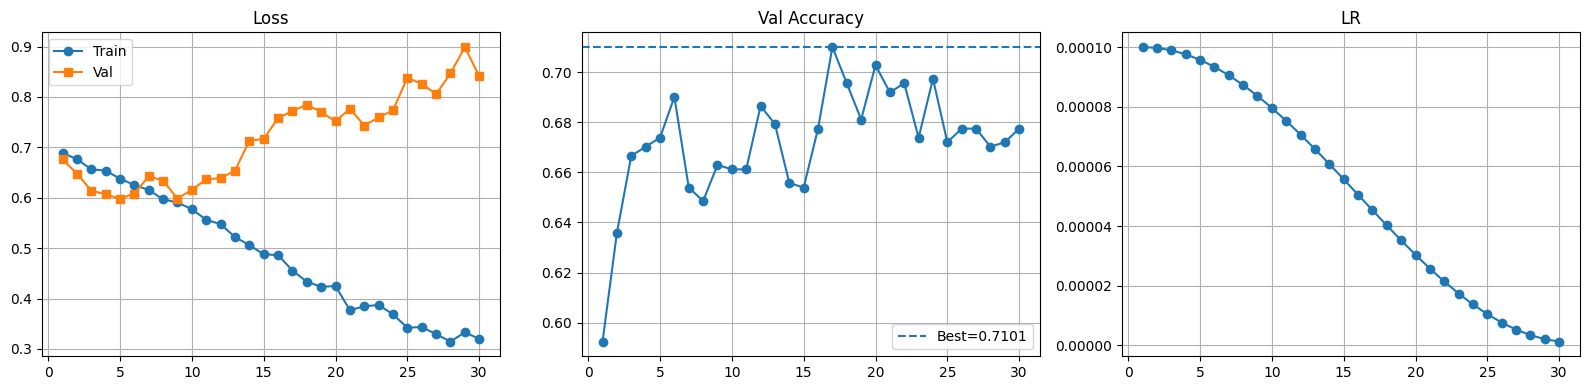

In [ ]:
x = range(1, len(train_losses)+1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(x, train_losses, 'o-', label='Train'); axes[0].plot(x, val_losses, 's-', label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(x, val_accs, 'o-'); axes[1].axhline(best_val_acc, ls='--', label=f'Best={best_val_acc:.4f}')
axes[1].set_title('Val Accuracy'); axes[1].legend(); axes[1].grid(True)
axes[2].plot(x, lr_history, 'o-'); axes[2].set_title('LR'); axes[2].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'training_curve_v3.png'), dpi=150); plt.show()


In [ ]:
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

all_preds, all_labels_e, all_probs = [], [], []
with torch.no_grad():
    for imgs, masks, labels in valid_loader:
        out = model(imgs.to(device), masks.to(device))
        all_probs.extend(F.softmax(out, 1)[:, 1].cpu().numpy())
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels_e.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels_e = np.array(all_labels_e)
all_probs = np.array(all_probs)


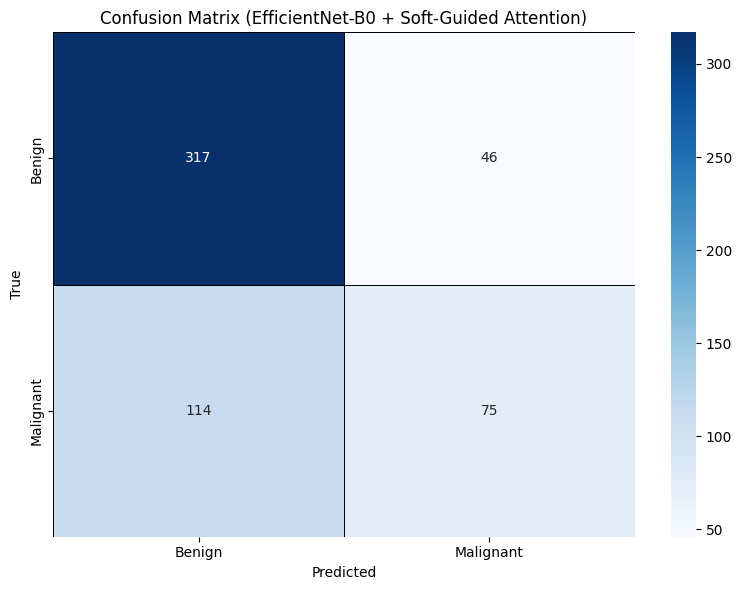


Accuracy: 0.7101 | Precision: 0.6198 | Recall: 0.3968 | F1: 0.4839
AUC: 0.7017

              precision    recall  f1-score   support

      Benign     0.7355    0.8733    0.7985       363
   Malignant     0.6198    0.3968    0.4839       189

    accuracy                         0.7101       552
   macro avg     0.6777    0.6351    0.6412       552
weighted avg     0.6959    0.7101    0.6908       552



In [ ]:
CN = ['Benign', 'Malignant']
cm = confusion_matrix(all_labels_e, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CN, yticklabels=CN,
            linewidths=0.5, linecolor='black')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix (EfficientNet-B0 + Soft-Guided Attention)')
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'confusion_matrix_v3.png'), dpi=150, bbox_inches='tight'); plt.show()

acc  = accuracy_score(all_labels_e, all_preds)
prec = precision_score(all_labels_e, all_preds, average='binary')
rec  = recall_score(all_labels_e, all_preds, average='binary')
f1   = f1_score(all_labels_e, all_preds, average='binary')
try:    auc = roc_auc_score(all_labels_e, all_probs)
except: auc = None

print(f"\nAccuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
if auc: print(f"AUC: {auc:.4f}")
print("\n" + classification_report(all_labels_e, all_preds, target_names=CN, digits=4))


In [ ]:
class GradCAM:
    """Grad-CAM adapted for model that takes (image, mask) as input."""
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def generate(self, img_tensor, mask_tensor, target_class=None):
        self.model.eval()
        out = self.model(img_tensor, mask_tensor)
        probs = torch.softmax(out, 1)
        if target_class is None:
            target_class = out.argmax(1).item()
        prob = probs[0, target_class].item()
        self.model.zero_grad()
        out[0, target_class].backward()

        w = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = torch.relu((w * self.activations).sum(1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cv2.resize(cam, (img_tensor.shape[3], img_tensor.shape[2])), target_class, prob


def overlay_heatmap(image, heatmap, alpha=0.4):
    """Overlay Grad-CAM heatmap on grayscale image."""
    if image.ndim == 2:
        img3 = np.stack([image]*3, -1)
    elif image.shape[0] == 1:
        img3 = np.stack([image[0]]*3, -1)
    else:
        img3 = image
    hm = cv2.applyColorMap((heatmap*255).astype(np.uint8), cv2.COLORMAP_JET)
    hm = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB) / 255.0
    return np.clip((1-alpha)*img3 + alpha*hm, 0, 1)


/tmp/ipykernel_5720/4103427952.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


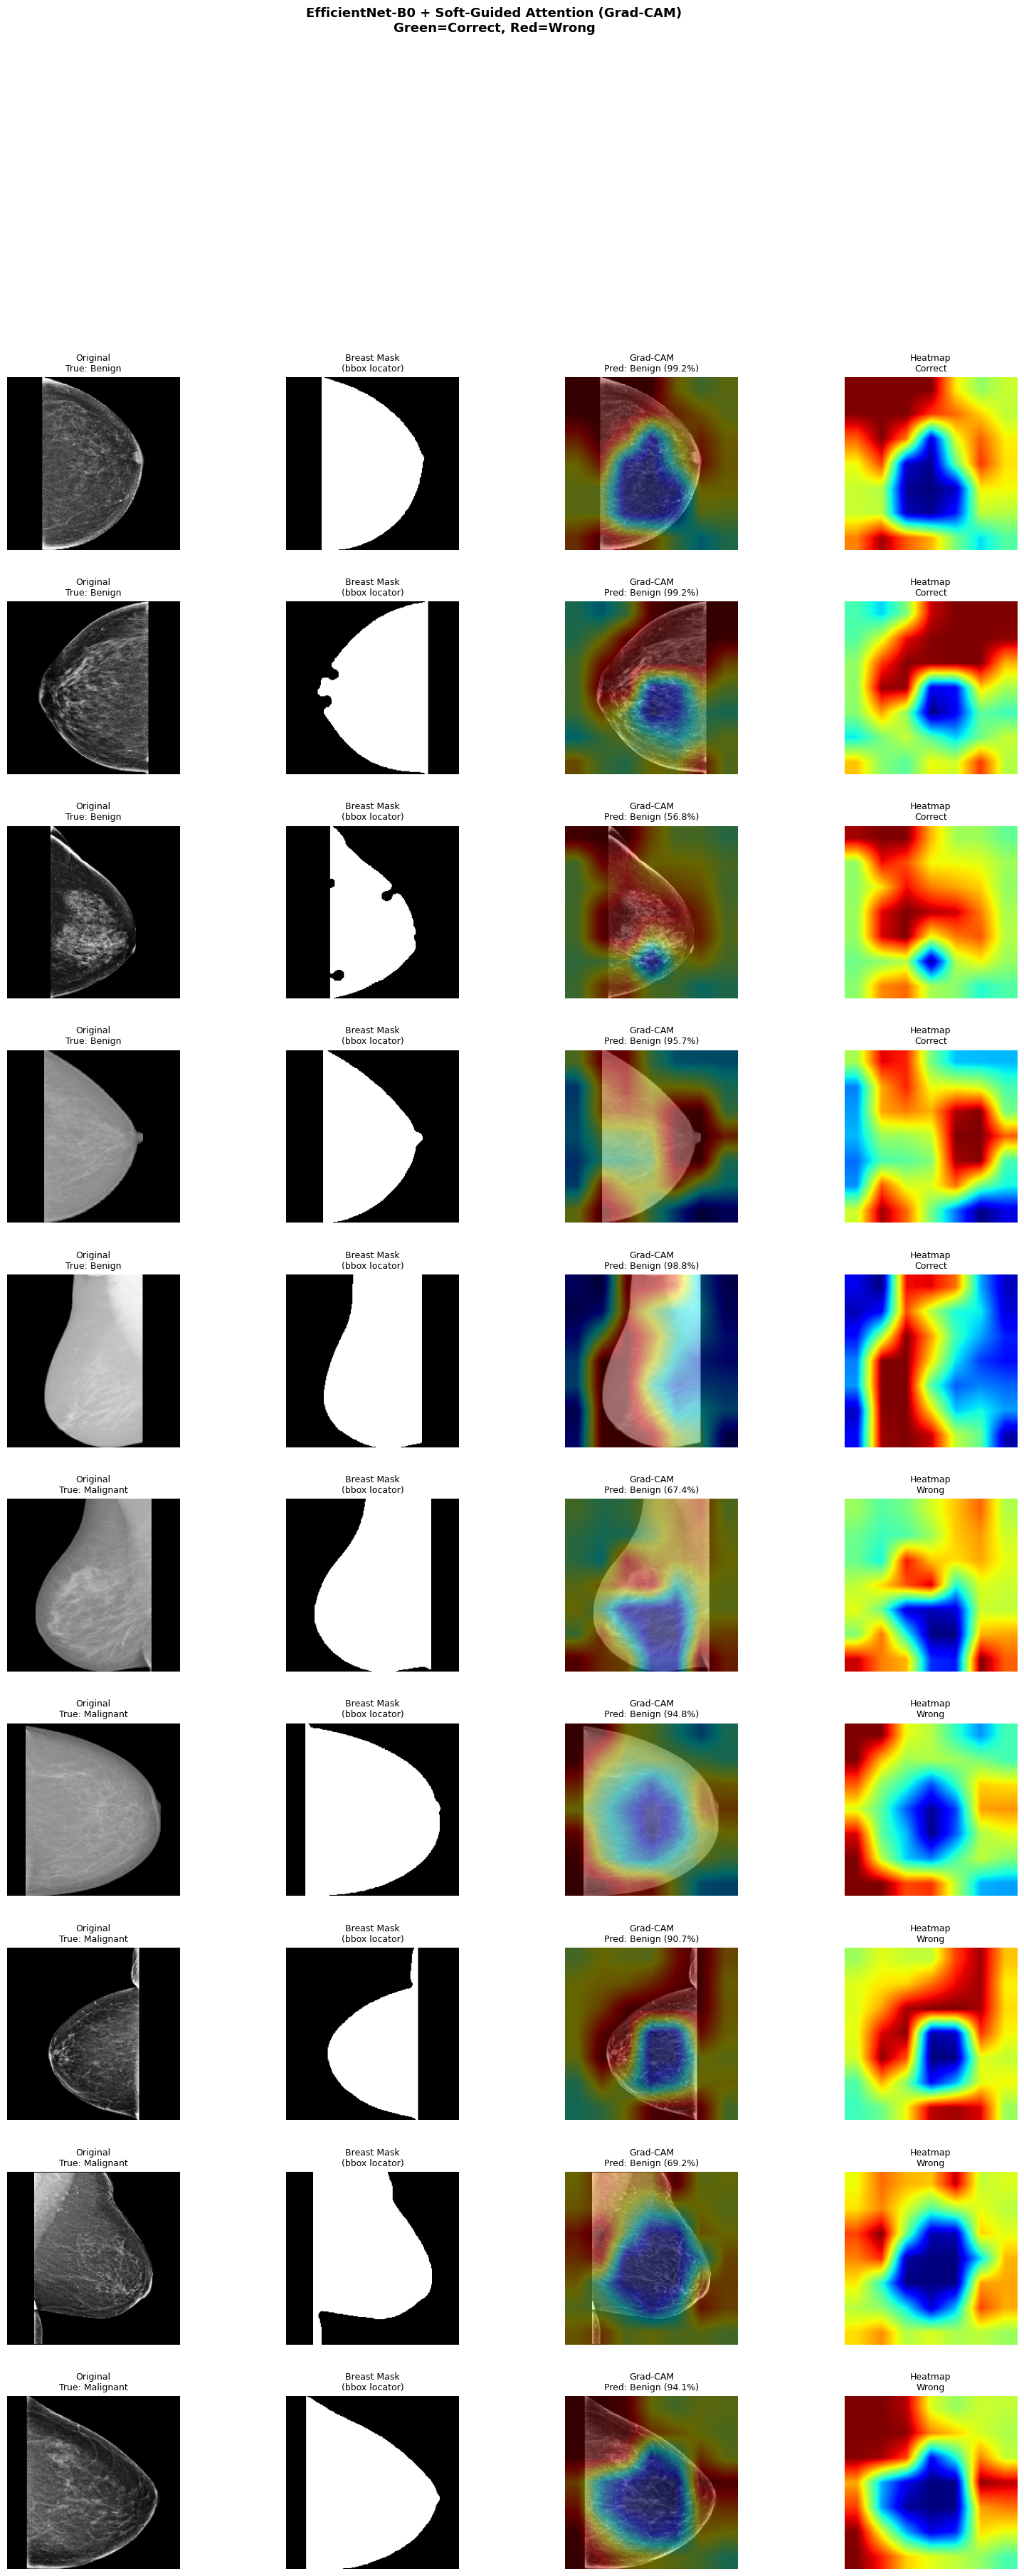

In [ ]:
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
disable_inplace(model)

# Target the soft-guided attention layer
grad_cam = GradCAM(model, target_layer=model.attention.spatial_conv)

n_per = 5
b_idx = [i for i, l in enumerate(valid_ds.labels) if l == 0]
m_idx = [i for i, l in enumerate(valid_ds.labels) if l == 1]
np.random.seed(42)
sel = np.concatenate([
    np.random.choice(b_idx, min(n_per, len(b_idx)), replace=False),
    np.random.choice(m_idx, min(n_per, len(m_idx)), replace=False)
])

fig = plt.figure(figsize=(20, 4*len(sel)))
gs = gridspec.GridSpec(len(sel), 4, wspace=0.05, hspace=0.3)

for row, idx in enumerate(sel):
    img_t, msk_t, true_lbl = valid_ds[idx]
    inp = img_t.unsqueeze(0).to(device).requires_grad_(True)
    msk = msk_t.unsqueeze(0).to(device)

    hm, pred, prob = grad_cam.generate(inp, msk)
    orig = img_t[0].numpy()
    ov = overlay_heatmap(orig, hm)
    mask_np = msk_t[0].numpy()

    ok = pred == true_lbl
    col = 'green' if ok else 'red'
    tag = 'Correct' if ok else 'Wrong'

    for ci, (im, cmap_, ttl) in enumerate([
        (orig,    'gray', f'Original\nTrue: {CN[true_lbl]}'),
        (mask_np, 'gray', 'Breast Mask\n(bbox locator)'),
        (ov,      None,   f'Grad-CAM\nPred: {CN[pred]} ({prob:.1%})'),
        (hm,      'jet',  f'Heatmap\n{tag}'),
    ]):
        ax = fig.add_subplot(gs[row, ci])
        if cmap_: ax.imshow(im, cmap=cmap_, vmin=0, vmax=1)
        else:     ax.imshow(im)
        ax.set_title(ttl, fontsize=9); ax.axis('off')
        if ci in [0, 2, 3]:
            for sp in ax.spines.values():
                sp.set_edgecolor(col); sp.set_linewidth(3); sp.set_visible(True)

plt.suptitle('EfficientNet-B0 + Soft-Guided Attention (Grad-CAM)\n'
             'Green=Correct, Red=Wrong', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'gradcam_v3.png'), dpi=150, bbox_inches='tight'); plt.show()


Comparison: Soft-guided attention WITH vs WITHOUT breast mask


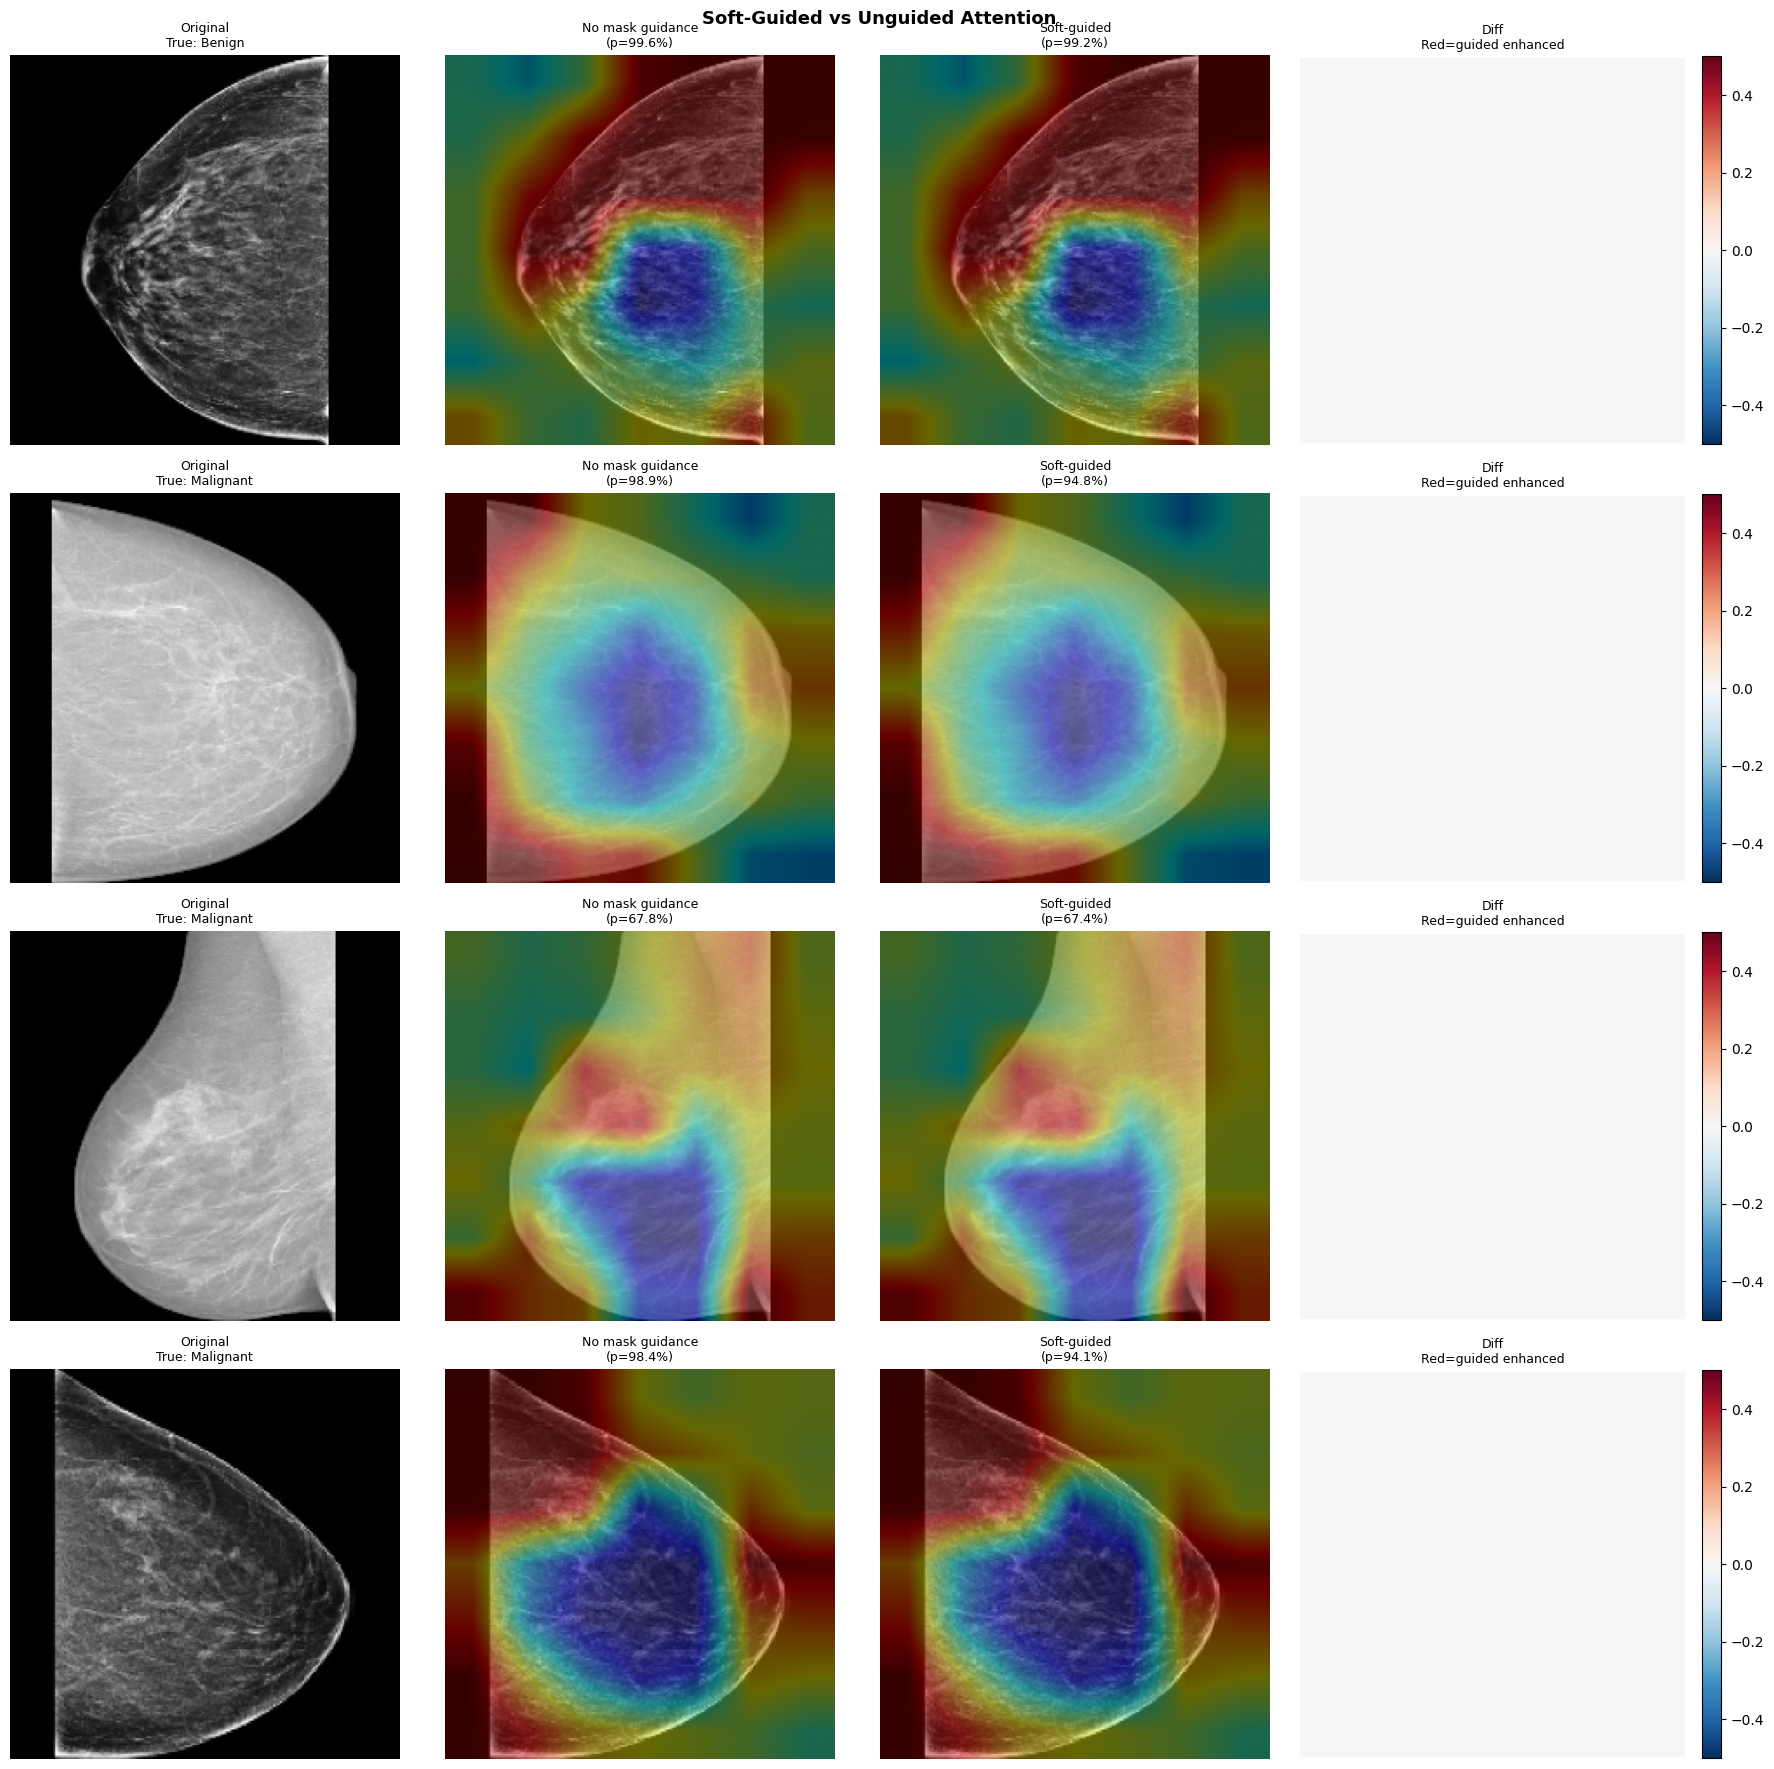

In [ ]:
print("=" * 70)
print("Comparison: Soft-guided attention WITH vs WITHOUT breast mask")
print("=" * 70)

n_cmp = 4
cmp_idx = np.random.choice(sel, min(n_cmp, len(sel)), replace=False)
fig, axes = plt.subplots(n_cmp, 4, figsize=(18, 4.5*n_cmp))
if n_cmp == 1: axes = axes.reshape(1, -1)

for row, idx in enumerate(cmp_idx):
    img_t, msk_t, tl = valid_ds[idx]
    orig = img_t[0].numpy()

    hm_w, _, pw = grad_cam.generate(img_t.unsqueeze(0).to(device).requires_grad_(True),
                                     msk_t.unsqueeze(0).to(device))
    hm_wo, _, pwo = grad_cam.generate(img_t.unsqueeze(0).to(device).requires_grad_(True),
                                       None)
    diff = hm_w - hm_wo

    axes[row,0].imshow(orig, cmap='gray')
    axes[row,0].set_title(f'Original\nTrue: {CN[tl]}', fontsize=9); axes[row,0].axis('off')
    axes[row,1].imshow(overlay_heatmap(orig, hm_wo))
    axes[row,1].set_title(f'No mask guidance\n(p={pwo:.1%})', fontsize=9); axes[row,1].axis('off')
    axes[row,2].imshow(overlay_heatmap(orig, hm_w))
    axes[row,2].set_title(f'Soft-guided\n(p={pw:.1%})', fontsize=9); axes[row,2].axis('off')
    im = axes[row,3].imshow(diff, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    axes[row,3].set_title('Diff\nRed=guided enhanced', fontsize=9); axes[row,3].axis('off')
    plt.colorbar(im, ax=axes[row,3], fraction=0.046, pad=0.04)

plt.suptitle('Soft-Guided vs Unguided Attention', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'guided_vs_unguided_v3.png'), dpi=150, bbox_inches='tight'); plt.show()


Analyzing: 100%|██████████| 50/50 [00:01<00:00, 27.64it/s]
/tmp/ipykernel_5720/2053811385.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(d, labels=lb, patch_artist=True)
/tmp/ipykernel_5720/2053811385.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(d, labels=lb, patch_artist=True)
/tmp/ipykernel_5720/2053811385.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(d, labels=lb, patch_artist=True)



CORRECT (n=32):
  In-breast ratio: 0.413 +/- 0.136
  Max attention:   0.937 +/- 0.242
  Spread (std):    0.223 +/- 0.068

WRONG (n=18):
  In-breast ratio: 0.391 +/- 0.121
  Max attention:   0.944 +/- 0.229
  Spread (std):    0.226 +/- 0.063


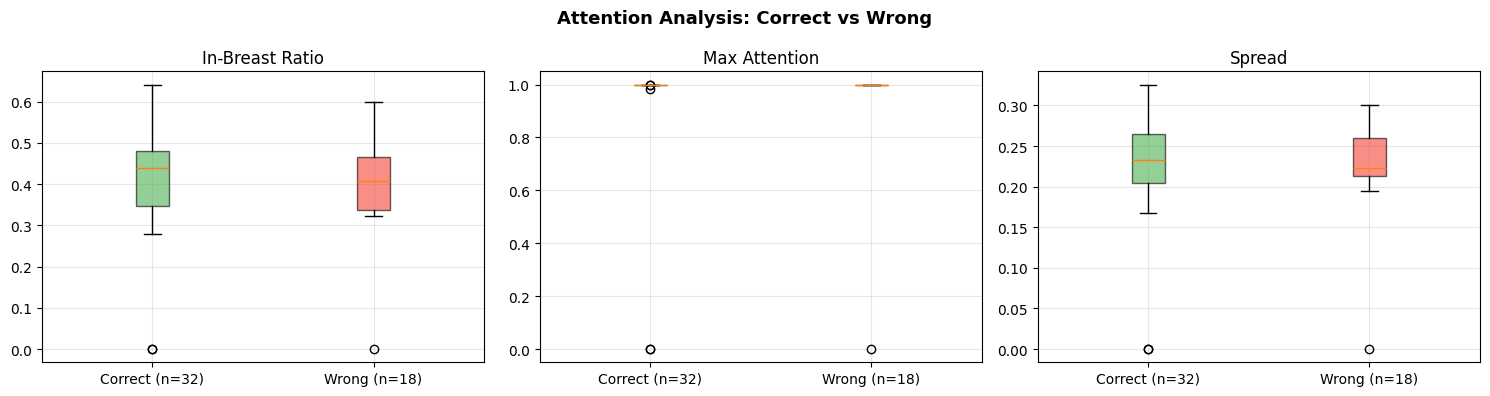


Learned alpha (mask influence): 0.502
  alpha ~0 = model ignores mask, pure self-attention
  alpha ~1 = model relies heavily on mask guidance
  Ideal: 0.3-0.7 range = model uses mask as soft hint, not hard constraint


In [ ]:
n_ana = min(50, len(valid_ds))
ana_idx = np.random.choice(len(valid_ds), n_ana, replace=False)
att_s = {'correct': {'in_breast': [], 'max': [], 'std': []},
         'wrong':   {'in_breast': [], 'max': [], 'std': []}}

gc_stat = GradCAM(model, target_layer=model.attention.spatial_conv)

for idx in tqdm(ana_idx, desc="Analyzing"):
    img_t, msk_t, tl = valid_ds[idx]
    hm, pred, _ = gc_stat.generate(img_t.unsqueeze(0).to(device).requires_grad_(True),
                                    msk_t.unsqueeze(0).to(device))
    mk = cv2.resize(msk_t[0].numpy(), (hm.shape[1], hm.shape[0]), interpolation=cv2.INTER_NEAREST)
    key = 'correct' if pred == tl else 'wrong'
    att_s[key]['in_breast'].append(hm[mk > 0].sum() / (hm.sum() + 1e-8))
    att_s[key]['max'].append(hm.max())
    att_s[key]['std'].append(hm.std())

for key in ['correct', 'wrong']:
    n = len(att_s[key]['in_breast'])
    if n > 0:
        tag = 'CORRECT' if key == 'correct' else 'WRONG'
        print(f"\n{tag} (n={n}):")
        print(f"  In-breast ratio: {np.mean(att_s[key]['in_breast']):.3f} +/- {np.std(att_s[key]['in_breast']):.3f}")
        print(f"  Max attention:   {np.mean(att_s[key]['max']):.3f} +/- {np.std(att_s[key]['max']):.3f}")
        print(f"  Spread (std):    {np.mean(att_s[key]['std']):.3f} +/- {np.std(att_s[key]['std']):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (m, t) in enumerate([('in_breast','In-Breast Ratio'),('max','Max Attention'),('std','Spread')]):
    d, lb = [], []
    for k, l in [('correct',f'Correct (n={len(att_s["correct"][m])})'),
                 ('wrong',  f'Wrong (n={len(att_s["wrong"][m])})')]:
        if att_s[k][m]: d.append(att_s[k][m]); lb.append(l)
    if d:
        bp = axes[i].boxplot(d, labels=lb, patch_artist=True)
        for p, c in zip(bp['boxes'], ['#4CAF50','#F44336'][:len(d)]):
            p.set_facecolor(c); p.set_alpha(0.6)
    axes[i].set_title(t); axes[i].grid(True, alpha=0.3)

plt.suptitle('Attention Analysis: Correct vs Wrong', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'attention_stats_v3.png'), dpi=150, bbox_inches='tight'); plt.show()

print(f"\nLearned alpha (mask influence): {torch.sigmoid(model.attention.alpha_raw).item():.3f}")
print("  alpha ~0 = model ignores mask, pure self-attention")
print("  alpha ~1 = model relies heavily on mask guidance")
print("  Ideal: 0.3-0.7 range = model uses mask as soft hint, not hard constraint")
